# Building an Assistant

Sub-goals, controlability, external tools, and parallelisation

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
| 26/05/26   | Martin | CREATE   |  | 

# Content

* [Introduction](#introduction)

# Parallelisation

Running multiple nodes that update the state at the same time. _Fan-in-fan-out_ is one of the ways a graph can be contructed to run in parallel i.e at least 2 nodes running at the same time.

__BUT__ because the state is always overridden, a __reducer__ is required to run parallel nodes

In [2]:
import operator

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph
from langgraph.constants import START, END

from IPython.display import Image, display

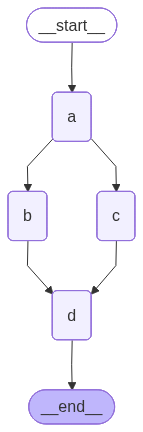

In [3]:
class State(TypedDict):
    state: Annotated[list, operator.add]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State):
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}

builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A."))
builder.add_node("b", ReturnNodeValue("I'm B."))
builder.add_node("c", ReturnNodeValue("I'm C."))
builder.add_node("d", ReturnNodeValue("I'm D."))

builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

__🧑‍🏫 LESSON:__ Here because nodes "b" and "c" need to simultaneously update the state (which by default will override) we use the `operator.add` with a custom State to ensure values get appended

In [4]:
graph.invoke({"state": []})

Adding I'm A. to []
Adding I'm B. to ["I'm A."]
Adding I'm C. to ["I'm A."]
Adding I'm D. to ["I'm A.", "I'm B.", "I'm C."]


{'state': ["I'm A.", "I'm B.", "I'm C.", "I'm D."]}

In [ ]:
%load_ext watermark
%watermark